In [1]:
import os
import sys 
from pathlib import Path 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd()
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)
    
from sklearn.model_selection import train_test_split
from src.data_loader import DataCleaner
from src.explanability import (PartialDependencePipeline, 
                               ShapPipelineExplainer,
                               LimePipelineExplainer,
                               MAPOCAM,
                               Dice
)
from src.models import get_models
from src.training import create_pipeline
from src.evaluate import get_metrics

%load_ext autoreload
%autoreload 2

In [2]:
# Load dataset Home Credit
cleaner = DataCleaner()
df_train, df_test = cleaner.run_cleaner()

[data]  found 9 raw file(s)
  ← application_test.csv  shape=(48744, 121)
  ← application_train.csv  shape=(307511, 122)
  ← bureau.csv  shape=(1716428, 17)
  ← bureau_balance.csv  shape=(27299925, 3)
  ← credit_card_balance.csv  shape=(3840312, 23)
  ← installments_payments.csv  shape=(13605401, 8)
  ← POS_CASH_balance.csv  shape=(10001358, 8)
  ← previous_application.csv  shape=(1670214, 37)
  ← sample_submission.csv  shape=(48744, 2)
[data]  train shape: (307511, 119)
[data]  test  shape: (48744, 118)
[data]  saved successfully!


In [3]:
# Train/ Val/ Test
seed = 42 

X_train = df_train.drop(columns=["DEFAULT"])
y_train = df_train["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

classifiers = get_models()
rf_classifier = classifiers['Random Forest']

pipeline = create_pipeline(
    X_train,
    y_train,
    classifier = rf_classifier,
    cat_cols = "infer",
    onehot = True,
    onehotdrop = False,
    normalize = True,
    do_EBE = True,
)
pipeline.fit(X_train, y_train)


background_samples = 100
n_samples = 1000
X_background = X_train.sample(n=background_samples, random_state=seed)
X_sample = X_train.sample(n=n_samples, random_state=seed)

In [4]:
import joblib

models_path = os.path.join(BASE_DIR, "outputs","models" )
model = joblib.load(os.path.join(models_path, "randomforest_params_optimized.joblib"))

## Global Importances

In [7]:
from matplotlib.patches import Patch as mpatches
from matplotlib.colors import to_hex

def parallel_coordinates(
    df,
    columns,
    columns_ranges = None,
    columns_tick_format = None,
    columns_names = None,
    color_column = None,
    color_mapper = None,
    name_mapper = None,
    legend_order = None,
    title = None
):
    """
    Simple parallel coordinates to plot the projection results.
    """
    norm_df = df.copy() # dataframe will be normalized

    fig, axes = plt.subplots(len(columns)-1, 1, sharex=False, figsize=(5,10))

    if columns_ranges is None:
        columns_ranges = [None for _ in columns]
    if columns_tick_format is None:
        columns_tick_format = [lambda x : np.round(x, 1) for _ in columns]

    # Get min, max and range for each column
    # Normalize the data for each column
    min_max_range = {}
    for i, col in enumerate(columns):
        if columns_ranges[i] is None:
            col_max = df[col].max()
            col_min = df[col].min()
        else:
            col_max = columns_ranges[i][1]
            col_min = columns_ranges[i][0]

        min_max_range[col] = [col_min, col_max]
        col_range = col_max - col_min
        if col_range == 0:
            col_range = 1
        norm_df[col] = (df[col] - col_min) / col_range

    # Invert to plot first columns at the top
    x = list(range(len(columns)))[::-1]
    axx = axes[0].twiny()
    # Plot each row
    if color_column is None:
        for i, ax in enumerate(axes):
            for idx in norm_df.index:
                ax.plot(norm_df.loc[idx, columns], x, c = "#80b1d3", lw = 3)
        for idx in norm_df.index:
            axx.plot(norm_df.loc[idx, columns], x, c = "#80b1d3", lw = 3)
    else:
        color_values = norm_df[color_column].unique()
        colormap = plt.get_cmap("Paired")
        if color_column is not None and color_mapper is None:
            color_mapper = {color_value: colormap(i) for i, color_value in enumerate(color_values)}

        for ii, value in enumerate(color_values):
            df_value = norm_df[norm_df[color_column] == value]
            for i, ax in enumerate(axes[:-1]):
                for idx in df_value.index:
                    ax.plot(df_value.loc[idx, columns], x, alpha = 0.85, lw = 5, label = value, c = color_mapper[value])
            for idx in df_value.index:
                axx.plot(df_value.loc[idx, columns], x, alpha = 0.85, lw = 5, label = value, c = color_mapper[value])
    
    for i, ax in enumerate(axes):
        ax.set_ylim([x[i+1], x[i]])
        ax.set_xlim([-0.05, 1.05])
        xticks = ax.get_xticks()
        col_min = min_max_range[columns[i]][0]
        col_max = min_max_range[columns[i]][1]
        col_range = col_max - col_min
        format_ = columns_tick_format[i]
        ax.set_xticklabels([format_(yi * col_range  + col_min)  for yi in xticks], fontsize = 14)
    
    axes[0].set_xlim([-0.05, 1.05])

    for i, ax in enumerate(axes):
        #ax.yaxis.set_major_locator(ticker.FixedLocator([i+1]))
        ax.set_yticks([len(axes) - i])
        ax.set_yticklabels([columns_names[i]], fontsize = 18)

    axes[-1].set_yticks([0, 1])
    axes[-1].set_yticklabels([columns_names[-2], columns_names[-1]], fontsize = 18)

    # tick for right side of last axis
    axx.set_facecolor("none")
    xticks = axes[-1].get_xticks()
    col_min = min_max_range[columns[len(axes)]][0]
    col_max = min_max_range[columns[len(axes)]][1]
    col_range = col_max - col_min
    format_ = columns_tick_format[len(axes)]
    if format_ is None:
        axx.set_xticklabels([np.round((yi * col_range +  col_min), 1)  for yi in xticks], fontsize = 14)
    else:
        axx.set_xticklabels([format_(yi * col_range +  col_min)  for yi in xticks], fontsize = 14)
    #axx.xaxis.tick_top()
    #axx.set_axisbelow(True)
    #axx.set_xlim([-0.05, 1.05])
    #axx.spines['top'].set_visible(False)
    #axx.spines['bottom'].set_visible(False)

    for ax in list(axes) + [axx]:
        ax.set_facecolor("none")
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)


    
    if title:
        plt.suptitle(title, y = 1, fontsize = 20)
    # Remove space between subplots
    plt.subplots_adjust(hspace=0)

    if color_column is not None:
        handles = [
            mpatches.Patch(color=to_hex(color_mapper[value]), label=name_mapper[value]) for value in legend_order
        ]
        plt.legend(handles = handles, bbox_to_anchor=(1.3, 1), ncol = len(legend_order))

Let's use SHAP to obtain global feature importances.

In [8]:
explainer = ShapPipelineExplainer(
    pipeline,
    X_train.sample(n = background_samples, random_state = seed),
    method_explain="pred",
    threshold = 0.5
)

importances = explainer(X_train.sample(n = n_samples, random_state = seed))
shap_features_names = importances.columns.tolist()
shap_features_importance = importances.abs().mean().values
shap_features_importance = pd.DataFrame(
    np.array(shap_features_importance).reshape(1, -1), columns=shap_features_names
)

PermutationExplainer explainer: 1001it [10:15,  1.61it/s]                          


In [9]:
def filter_importance_features(df_importance):
    """Get the median (abs) importance of each feature and select the 10 featuers with highest median importance."""
    importance_values = df_importance.values
    median_importance = np.median(np.abs(importance_values), axis=0)
    sorted_idx = np.argsort(median_importance)[::-1][:10]
    features = df_importance.columns.tolist()
    features_sorted = np.array(features)[sorted_idx]
    return features_sorted

In [11]:
def plot_pc_importances(df_importance, title = ""):
    features = filter_importance_features(df_importance).tolist()
    n_f = len(features)
    imp_range = [
        df_importance[features].values.min(), df_importance[features].values.max()
    ]
    tick_format = lambda x : f"{x:.2f}"
    parallel_coordinates(
        df_importance,
        features,
        columns_ranges = [imp_range for _ in range(n_f)],
        columns_tick_format = [tick_format for _ in range(n_f)],
        columns_names = features,
        title = title
    )

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28628\3106295443.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_(yi * col_range  + col_min)  for yi in xticks], fontsize = 14)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28628\3106295443.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_(yi * col_range  + col_min)  for yi in xticks], fontsize = 14)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28628\3106295443.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_(yi * col_range  + col_min)  for yi in xticks], fontsize = 14)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28628\3106295443.py:77: UserWarning: set_ticklabels() should only be used with a fixed numbe

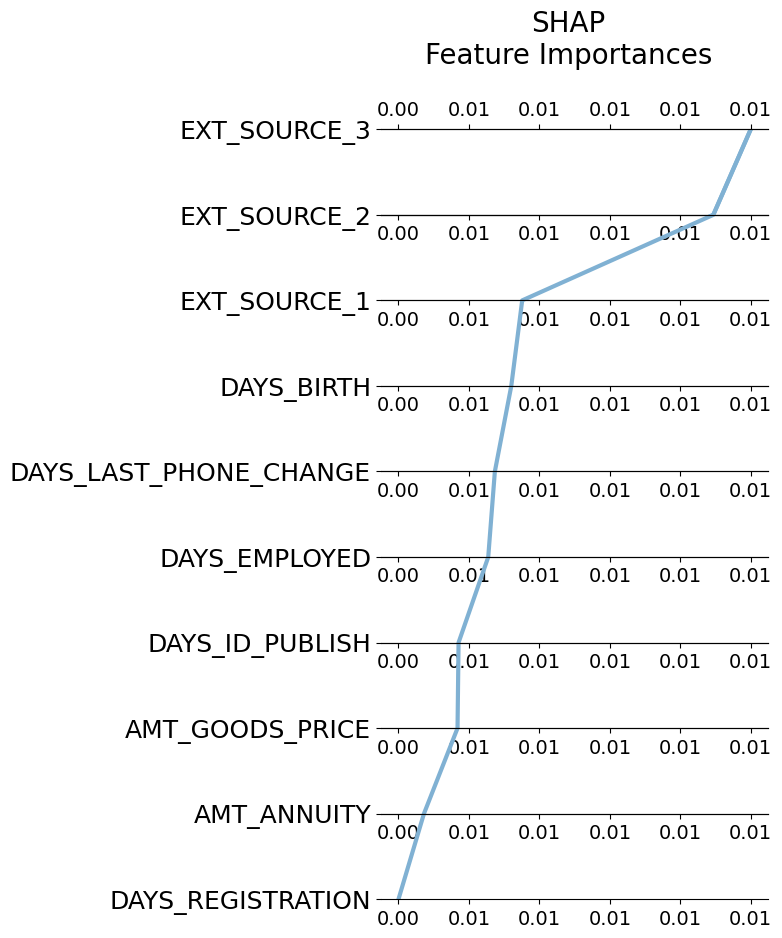

In [12]:
plot_pc_importances(
    shap_features_importance, "SHAP\nFeature Importances",
)

## PDP

In [13]:
def plot_pdp(model_list, X, selected_feature):
    fig, axs = plt.subplots(nrows = 1, ncols = len(model_list), figsize = (int(4 * len(model_list)), 4))
    if len(model_list) == 1:
        axs = [axs]
    

    for i, model in enumerate(model_list):
        explainer = PartialDependencePipeline(model)
        pdp = explainer(X, selected_feature)
        if len(selected_feature) == 1:
            name = selected_feature[0]
            pdp["values"] = pdp["values"][0]
            pdp["prediction"] = pdp["prediction"][0]
            pdp["deciles"] = pdp["deciles"][0]
        
            axs[i].plot(pdp["values"], pdp["prediction"])
            axs[i].set_title(model[-1].__class__.__name__)
            axs[i].set_xlabel(name)
            axs[i].set_ylabel("Probability of Default")

            for decile in pdp["deciles"]:
                axs[i].axvline(decile, ymin = 0, ymax = 0.05, color = "#606060", alpha = 0.9)

        else:
            assert len(selected_feature) == 2
            pdp["prediction"] = pdp["prediction"][0, :, :]
            axs[i].imshow(pdp["prediction"], cmap = "viridis", aspect = "auto")


    
    plt.suptitle(f"Partial Dependence Plot for {selected_feature}", fontsize = 16)
    plt.tight_layout()

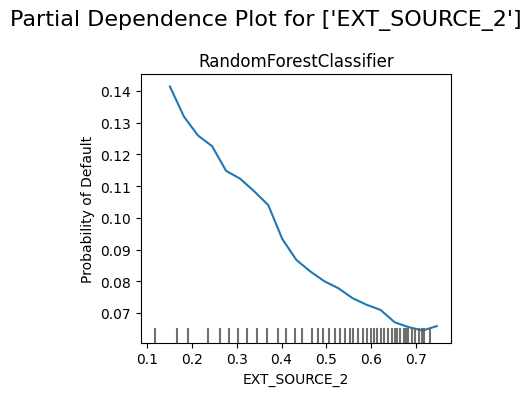

In [17]:
plot_pdp([pipeline], X_sample, ["EXT_SOURCE_2"])

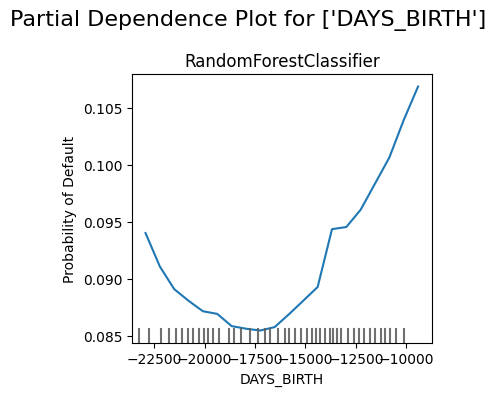

In [21]:
plot_pdp([pipeline], X_sample, ["DAYS_BIRTH"])

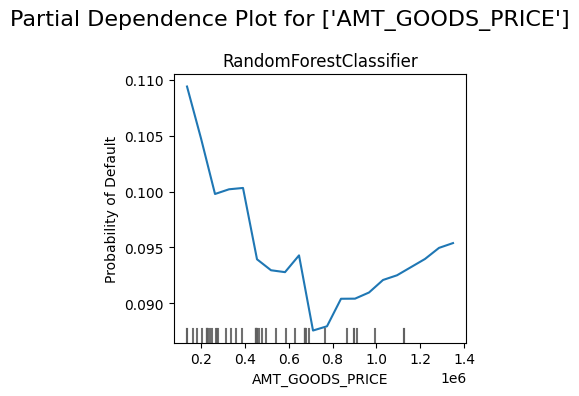

In [22]:
plot_pdp([pipeline], X_sample, ["AMT_GOODS_PRICE"])

## ICE

In [15]:
def plot_ice(model_list, X, selected_feature, color_by = None):
    fig, axs = plt.subplots(nrows = 1, ncols = len(model_list), figsize = (int(4* len(model_list)), 4))
    if len(model_list) == 1:
        axs = [axs]


    if color_by is not None:
        vmax = np.quantile(X[color_by], 0.95)
        color_map = lambda x : plt.cm.plasma_r(x / vmax)
    else:
        color_map = lambda x : "#80b1d3"

    
    for i, model in enumerate(model_list):
        explainer = PartialDependencePipeline(model, kind = "individual")
        pdp = explainer(X, selected_feature)
        
        if len(selected_feature) == 1:
            pdp["values"] = pdp["values"][0]
            pdp["prediction"] = pdp["prediction"][0]
            pdp["deciles"] = pdp["deciles"][0]
        
        # reset to all lines start at 0
        pdp["prediction"] = pdp["prediction"] - pdp["prediction"][:, 0][:, np.newaxis]
        for j in range(X.shape[0]):
            c = color_map(X[color_by].values[j])
            axs[i].plot(pdp["values"], pdp["prediction"][j, :], c = c, alpha = 0.4)
        axs[i].set_title(model[-1].__class__.__name__)
        axs[i].set_xlabel(selected_feature[0])
        axs[i].set_ylabel("Probability of Default")

        for decile in pdp["deciles"]:
            axs[i].axvline(decile, ymin = 0, ymax = 0.05, color = "#606060", alpha = 0.9)


    if color_by is not None:
        sm = plt.cm.ScalarMappable(cmap = plt.cm.plasma_r, norm = plt.Normalize(vmin = 0, vmax = vmax))
        #sm.set_array(
        cbar = plt.colorbar(sm, ax = axs, orientation = "horizontal")
        cbar.set_label(color_by)
        
        cbar.ax.set_position([0.1, -0.2, 0.8, 0.05])
        # change ticks to be in scientific notation
        ticks = cbar.get_ticks()[::2]
        cbar.set_ticks(ticks)
        ticks = ["{:.1E}".format(t) for t in ticks]
        cbar.set_ticklabels(ticks)

    plt.suptitle(f"Individual Conditional Expectation for {selected_feature[0]}", fontsize = 16)          
    plt.tight_layout(w_pad=0.3)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28628\2241322151.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.3)


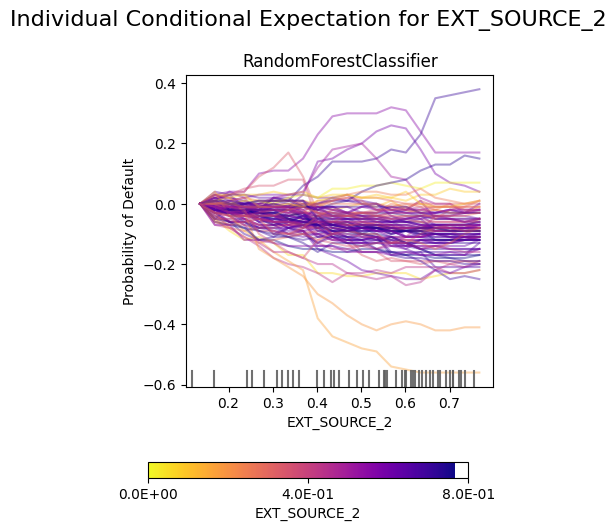

In [18]:
plot_ice([pipeline], X_sample.head(100), ["EXT_SOURCE_2"], color_by="EXT_SOURCE_2")

## SHAP and LIME

Ref for shap handling of categorical features: https://github.com/shap/shap/issues/397

In [19]:
shap_explainer = ShapPipelineExplainer(pipeline, X_sample, method_explain="prob")
lime_explainer = LimePipelineExplainer(pipeline, X_sample, method_explain="prob")

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


{104: ['Cash loans', 'Revolving loans'], 105: ['N', 'Y'], 106: ['N', 'Y'], 107: ['No', 'Yes'], 108: ['F', 'M', 'XNA'], 109: ['Unaccompanied', 'Family', 'Spouse, partner', 'Other_B', 'Children', 'Group of people', 'Other_A'], 110: ['Working', 'Commercial associate', 'State servant', 'Pensioner', 'Student', 'Unemployed', 'Businessman', 'Maternity leave'], 111: ['Incomplete higher', 'Higher education', 'Secondary / secondary special', 'Lower secondary', 'Academic degree'], 112: ['Married', 'Widow', 'Single / not married', 'Civil marriage', 'Separated', 'Unknown'], 113: ['House / apartment', 'Municipal apartment', 'With parents', 'Office apartment', 'Rented apartment', 'Co-op apartment'], 114: ['SATURDAY', 'FRIDAY', 'TUESDAY', 'THURSDAY', 'WEDNESDAY', 'MONDAY', 'SUNDAY'], 115: ['reg oper account', 'org spec account', 'reg oper spec account', 'not specified'], 116: ['block of flats', 'specific housing', 'terraced house'], 117: ['Panel', 'Stone, brick', 'Block', 'Wooden', 'Monolithic', 'Othe

{104: ['Cash loans', 'Revolving loans'], 105: ['N', 'Y'], 106: ['N', 'Y'], 107: ['No', 'Yes'], 108: ['F', 'M', 'XNA'], 109: ['Unaccompanied', 'Family', 'Spouse, partner', 'Other_B', 'Children', 'Group of people', 'Other_A'], 110: ['Working', 'Commercial associate', 'State servant', 'Pensioner', 'Student', 'Unemployed', 'Businessman', 'Maternity leave'], 111: ['Incomplete higher', 'Higher education', 'Secondary / secondary special', 'Lower secondary', 'Academic degree'], 112: ['Married', 'Widow', 'Single / not married', 'Civil marriage', 'Separated', 'Unknown'], 113: ['House / apartment', 'Municipal apartment', 'With parents', 'Office apartment', 'Rented apartment', 'Co-op apartment'], 114: ['SATURDAY', 'FRIDAY', 'TUESDAY', 'THURSDAY', 'WEDNESDAY', 'MONDAY', 'SUNDAY'], 115: ['reg oper account', 'org spec account', 'reg oper spec account', 'not specified'], 116: ['block of flats', 'specific housing', 'terraced house'], 117: ['Panel', 'Stone, brick', 'Block', 'Wooden', 'Monolithic', 'Othe

Text(0.5, 0.98, 'LIME Explanation | Prob(Y = 1) = 0.00')

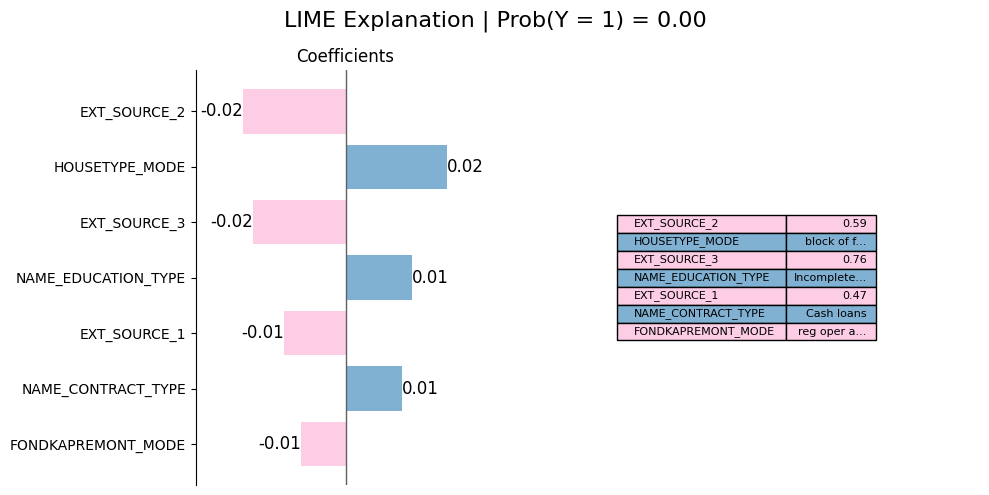

In [20]:
lime_explainer.plot_explanation(X_train.iloc[[2]])
prob = pipeline.predict_proba(X_train.iloc[[2]])[0, 1]
plt.suptitle(f"LIME Explanation | Prob(Y = 1) = {prob:.2f}", fontsize = 16)

Text(0.5, 0.98, 'SHAP Explanation | Prob(Y = 1) = 0.00')

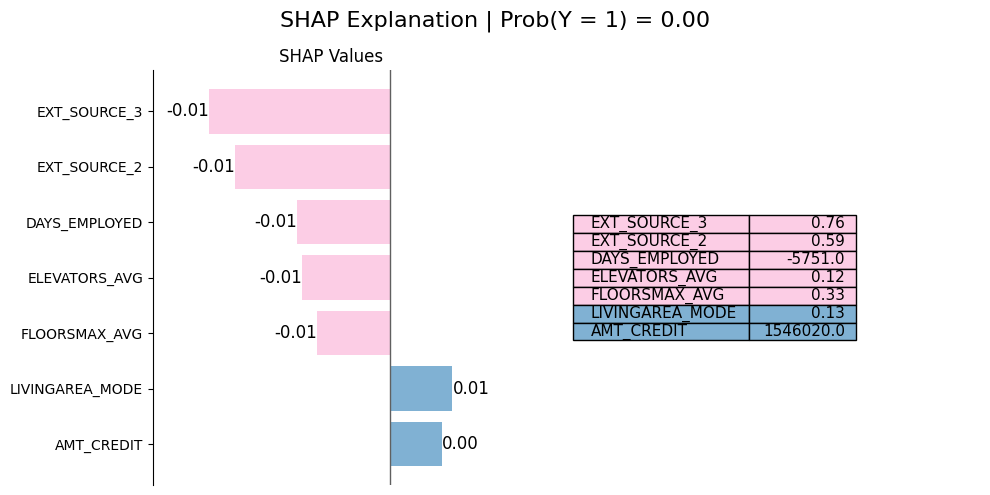

In [23]:
shap_explainer.plot_explanation(X_train.iloc[[2]])
prob = pipeline.predict_proba(X_train.iloc[[2]])[0, 1]
plt.suptitle(f"SHAP Explanation | Prob(Y = 1) = {prob:.2f}", fontsize = 16)

## MAPOCAM

In [24]:
X_train_positive = X_train[pipeline.predict(X_train) == 1]

In [30]:
mutable_features = [
    "AMT_INCOME_TOTAL",
    "DAYS_EMPLOYED",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_CHILDREN"
]

In [31]:
method = MAPOCAM(
    pipeline,
    X_train,
    mutable_features,
    target = 0,
    max_changes = 5,
    criteria = "percentile_changes",
    threshold=0.5,
    step_size = 0.01
)

In [32]:
cfs = method.fit(X_train_positive.iloc[[4]])

In [33]:
from src.explanability import display_cfs

display_cfs(X_train_positive.iloc[[4]], cfs, pipeline)

,Original,CF 0,CF 2,CF 1
AMT_INCOME_TOTAL,112500,112500,112500,100575
AMT_CREDIT,448056,448056,307298,325058
AMT_ANNUITY,21920,21920,21920,18326
DAYS_EMPLOYED,-1694.0,-7126.0,-3364.0,-3364.0


### Dice

In [34]:
method = Dice(
    X_train,
    y_train,
    pipeline,
    n_cfs = 3,
    mutable_features = mutable_features,
)

In [35]:
cfs = method.fit(X_train_positive.iloc[[4]])

  0%|          | 0/1 [00:00<?, ?it/s]d:\03 Data science\00 AIO2025\01 Projects\Case12.2_Credit_Risk\venv\Lib\site-packages\dice_ml\explainer_interfaces\dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  query_instance_df_dummies[col] = 0
100%|██████████| 1/1 [00:15<00:00, 15.62s/it]


In [36]:
display_cfs(X_train_positive.iloc[[4]], cfs, pipeline) 

,Original,CF 0,CF 1,CF 2
AMT_CREDIT,448056,448056,448056,45000
DAYS_EMPLOYED,-1694.0,-17912.0,-4806.0,-400.0
OWN_CAR_AGE,12,12,12,12
EXT_SOURCE_1,0.502,0.502,0.502,0.502
EXT_SOURCE_2,0.277,0.277,0.277,0.277
EXT_SOURCE_3,0.328,0.328,0.328,0.328
ENTRANCES_AVG,0.138,0.138,0.138,0.138
FLOORSMAX_AVG,0.167,0.167,0.167,0.167
FLOORSMIN_AVG,0.208,0.208,0.208,0.208
NONLIVINGAREA_AVG,0.046,0.046,0.046,0.046
